In [1]:
from data import CARLA_Data

import matplotlib.pyplot as plt
from config import GlobalConfig
import torch

# config = GlobalConfig()
# config.augment = False
# config.use_color_aug = False
# config.augment_percentage = 1
# config.color_aug_prob = 1
# config.max_num_trajectories = 10
# config.trajectory_pred_len = 6
# config.trajectory_decoder_layers = 1
# config.trajectory_modes = 6
# config.seq_len = 2
# config.seq_step = 1
# config.img_seq_len = 1
# config.img_step_size = 1
# config.lidar_seq_len = 1
# config.temporal_fusion_layers = 1
# config.use_temporal_fusion = True
# config.use_recurrent_training = True
# config.use_dataset_pruning = True
# config.return_temporal_attn_weights = True
# config.use_learnable_historic_initialization = True
# config.use_trajectory_prediction = True
# config.normalize_imagenet = True
# config.temporal_fusion_heads = 4
# config.initialize(
#     root_dir=[
#         # "/cluster/work/andrebw/repos/temporal_garage/results/data/garage_v2_2025_03_15/data"
#         "/cluster/work/andrebw/repos/temporal_garage/results/data/leaderboard_2/data"
#     ]
# )
# dataset = CARLA_Data(
#     root=config.data_roots,
#     config=config,
#     estimate_class_distributions=config.estimate_class_distributions,
#     estimate_sem_distribution=config.estimate_semantic_distribution,
#     # heuristic_pruning=config.use_dataset_pruning,
# )

device = "cuda"
BZ = 2  # // config.seq_len
# loader = iter(torch.utils.data.DataLoader(dataset, batch_size=BZ))


def extract_data(batch):
    return {
        "rgb": batch.get("temporal_rgb", batch["rgb"]).float().to(device),
        # "rgb": batch["rgb"].float().to(device),
        # "lidar_bev": batch.get("temporal_lidar", batch["lidar"]).float().to(device),
        "lidar_bev": batch["lidar"].float().to(device),
        "target_point": batch["target_point"].float().to(device),
        "ego_vel": batch["speed"].float().unsqueeze(1).to(device),
        # "ego_vel": vel.unsqueeze(1) if (vel:=batch["speed"].float().to(device)).shape.__len__()==1 else vel.unsqueeze(2),
        "command": batch["command"].float().to(device),
    }


def extract_targets(batch):
    return {
        "trajectories_label": batch["trajectories"].float().to(device),
        "trajectories_mask": batch["trajectories_mask"].float().to(device),
        "target_speed_label": batch["target_speed_twohot"].float().to(device),
        "checkpoint_label": batch["route"][:, : config.predict_checkpoint_len]
        .float()
        .to(device),
        "semantic_label": batch["semantic"].long().to(device),
        "bev_semantic_label": batch["bev_semantic"].long().to(device),
        "depth_label": batch["depth"].float().to(device),
        "center_heatmap_label": batch["center_heatmap"].float().to(device),
        "wh_label": batch["wh"].float().to(device),
        "yaw_class_label": batch["yaw_class"].long().to(device),
        "yaw_res_label": batch["yaw_res"].float().to(device),
        "offset_label": batch["offset"].float().to(device),
        "velocity_label": batch["velocity"].float().to(device),
        "brake_target_label": batch["brake_target"].long().to(device),
        "pixel_weight_label": batch["pixel_weight"].float().to(device),
        "avg_factor_label": batch["avg_factor"].float().to(device),
    }


def select(data, i):
    return {k: v[:, i] for k, v in data.items()}

index = 650
# loss_history = []
# data_point = next(loader)
# data_point = {k: torch.tensor(v).unsqueeze(0).repeat_interleave(2,0) for k, v in dataset[index].items()}

In [2]:
# zeros = 0
# non_zers = 0
# total_trajs = 0
# from tqdm import tqdm
# loader = torch.utils.data.DataLoader(dataset, batch_size=BZ, shuffle=True)
# for i, data_point in enumerate(tqdm(loader)):
#     traj = data_point['trajectories']

#     n_trajs = traj.shape[0] * traj.shape[1]
#     nonzero = traj.sum(dim=(2,3)).count_nonzero(dim=1).sum().item()
#     zero = n_trajs - nonzero
#     non_zers += nonzero
#     zeros += zero
#     total_trajs += n_trajs
#     if i == 2000:
#         break

# # Calculate zero/nonzero-class weights:
# nonzero_class_weights = total_trajs / (2 * non_zers)
# zero_class_weights = total_trajs / (2 * zeros)

# (nonzero_class_weights, zero_class_weights), (non_zers, zeros, total_trajs)

In [3]:
# non_zers, zeros, total_trajs

# # Calculate zero/nonzero-class weights:
# nonzero_class_weights = total_trajs / (2 * non_zers)
# zero_class_weights = total_trajs / (2 * zeros)

# nonzero_class_weights, zero_class_weights

In [4]:
import os
import jsonpickle
from model import LidarCenterNet

features = None

load_file = None
load_file = "../results/training/v2/static-LB5s1"
loaded_weights = None
if load_file:
    with open(os.path.join(load_file, "config.json"), "rt", encoding="utf-8") as f:
        json_config = f.read()
    loaded_config = jsonpickle.decode(json_config)
    config = GlobalConfig()
    config.__dict__.update(loaded_config.__dict__)
    loaded_weights = torch.load(
        f"{load_file}/model_0030.pth", map_location=device, weights_only=True
    )
config.return_temporal_attn_weights = True
net = LidarCenterNet(config).eval().to(device)
total_params = sum(p.numel() for p in net.parameters())
print(f"Total parameters: {total_params:_}")
if loaded_weights:
    missing_keys, unexpected_keys = net.load_state_dict(loaded_weights, strict=False)
    print(f"Missing modules:", list(set(missing_keys)))
    print(f"Unexpected modules:", list(set(unexpected_keys)))

features = None
index = 650



Total parameters: 123_598_022
Missing modules: []
Unexpected modules: []


In [5]:
config.initialize(
    root_dir=[
        # "/cluster/work/andrebw/repos/temporal_garage/results/data/garage_v2_2025_03_15/data"
        "/cluster/work/andrebw/repos/temporal_garage/results/data/leaderboard_2/data"
    ]
)
dataset = CARLA_Data(
    root=config.data_roots,
    config=config,
    estimate_class_distributions=config.estimate_class_distributions,
    estimate_sem_distribution=config.estimate_semantic_distribution,
    # heuristic_pruning=config.use_dataset_pruning,
)

device = "cuda"
BZ = 2  # // config.seq_len
loader = iter(torch.utils.data.DataLoader(dataset, batch_size=BZ))

Setting:  all
 54%|█████▍    | 21/39 [00:01<00:01, 12.88it/s]

/cluster/work/andrebw/repos/temporal_garage/team_code/data.py:157: UserWarning: Route was skipped due to not having enough frames for one full sequence (last_frame[9]<=first_frame[10]).
  warnings.warn(f"Route was skipped due to not having enough frames for one full sequence (last_frame[{last_frame}]<=first_frame[{first_frame}]).")
/cluster/work/andrebw/repos/temporal_garage/team_code/data.py:157: UserWarning: Route was skipped due to not having enough frames for one full sequence (last_frame[10]<=first_frame[10]).
  warnings.warn(f"Route was skipped due to not having enough frames for one full sequence (last_frame[{last_frame}]<=first_frame[{first_frame}]).")
/cluster/work/andrebw/repos/temporal_garage/team_code/data.py:157: UserWarning: Route was skipped due to not having enough frames for one full sequence (last_frame[8]<=first_frame[10]).
  warnings.warn(f"Route was skipped due to not having enough frames for one full sequence (last_frame[{last_frame}]<=first_frame[{first_frame}]).

100%|██████████| 39/39 [00:05<00:00,  6.71it/s]
Loading 289641 samples from 39 scenarios
Total amount of routes: 5368
Skipped routes: 226
Trainable routes: 3430
Maximum dataset size: 289641
Pruned 0 samples (0.0% of dataset)


In [6]:
# Find total parameter count of each top-level module of the network
for module_name, module in net.named_children():
    module_params = sum(p.numel() for p in module.parameters() if p.requires_grad)
    if module_params > 0:
        print(
            f"Total parameters in {module_name}: {module_params:_} ({module_params / total_params:.2%})"
        )

Total parameters in backbone: 106_566_276 (86.22%)
Total parameters in head: 186_070 (0.15%)
Total parameters in trajectory_head: 816_719 (0.66%)
Total parameters in semantic_decoder: 1_854_727 (1.50%)
Total parameters in bev_semantic_decoder: 37_643 (0.03%)
Total parameters in depth_decoder: 1_852_993 (1.50%)
Total parameters in target_speed_network: 67_848 (0.05%)
Total parameters in join: 9_473_024 (7.66%)
Total parameters in change_channel: 387_328 (0.31%)
Total parameters in checkpoint_decoder: 62_146 (0.05%)
Total parameters in extra_sensor_encoder: 34_048 (0.03%)
Total parameters in temporal_fusor: 2_125_056 (1.72%)


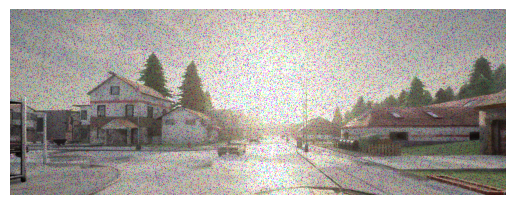

In [ ]:
# index += 1
index += 1
data_point = {
    k: torch.tensor(v).unsqueeze(0).repeat_interleave(2, 0)
    for k, v in dataset[index].items()
}
sample = data_point["rgb"][0, -1].numpy().transpose(1, 2, 0)
plt.axis("off")
plt.imshow(sample)

data_point = {
    k: torch.tensor(v).unsqueeze(0).repeat_interleave(2, 0)
    for k, v in dataset[index].items()
}
inputs = extract_data(data_point)
# index += 1

net.eval()
with torch.no_grad():
    (
        _,
        pred_target_speed,
        pred_checkpoint,
        pred_semantic,
        pred_bev_semantic,
        pred_depth,
        pred_bounding_box,
        pred_trajectories,
        pred_trajectories_confidence,
        _,
        _,
        _,
        attn_weights,
        # spatial_features,
        # spatiotemporal_features,
    ) = net.forward(
        **inputs,
    )


# features=spatiotemporal_features
def normalize_trajectories(trajectory):
    max_xy = np.array([config.trajectory_max_x, config.trajectory_max_y])
    min_xy = np.array([config.trajectory_min_x, config.trajectory_min_y])
    trajectory = trajectory - min_xy
    trajectory = trajectory / (max_xy - min_xy)
    return trajectory


def denormalize_trajectories(trajectory):
    max_xy = np.array([config.trajectory_max_x, config.trajectory_max_y])
    min_xy = np.array([config.trajectory_min_x, config.trajectory_min_y])
    trajectory = trajectory * (max_xy - min_xy)
    trajectory = trajectory + min_xy
    return trajectory


import numpy as np

sample_pred_trajectory = pred_trajectories[0].detach().cpu().numpy()
sample_pred_confidence = (
    pred_trajectories_confidence[0].softmax(-1).detach().cpu().numpy()
)
sample_pred_trajectory = sample_pred_trajectory[
    np.where(sample_pred_confidence[:, 1] > 0.4)
]
sample_traj = (
    extract_targets(data_point)["trajectories_label"][0].detach().cpu().numpy()
)
sample_traj_mask = (
    extract_targets(data_point)["trajectories_mask"][0].detach().cpu().numpy()
)
sample_traj = sample_traj[np.where(sample_traj_mask.sum(-1) != 0)]
# sample_traj = denormalize_trajectories(sample_traj)
sample_bev = extract_targets(data_point)["bev_semantic_label"][0].detach().cpu().numpy()
bb = data_point["bounding_boxes"]
bev = data_point["bev_semantic"]

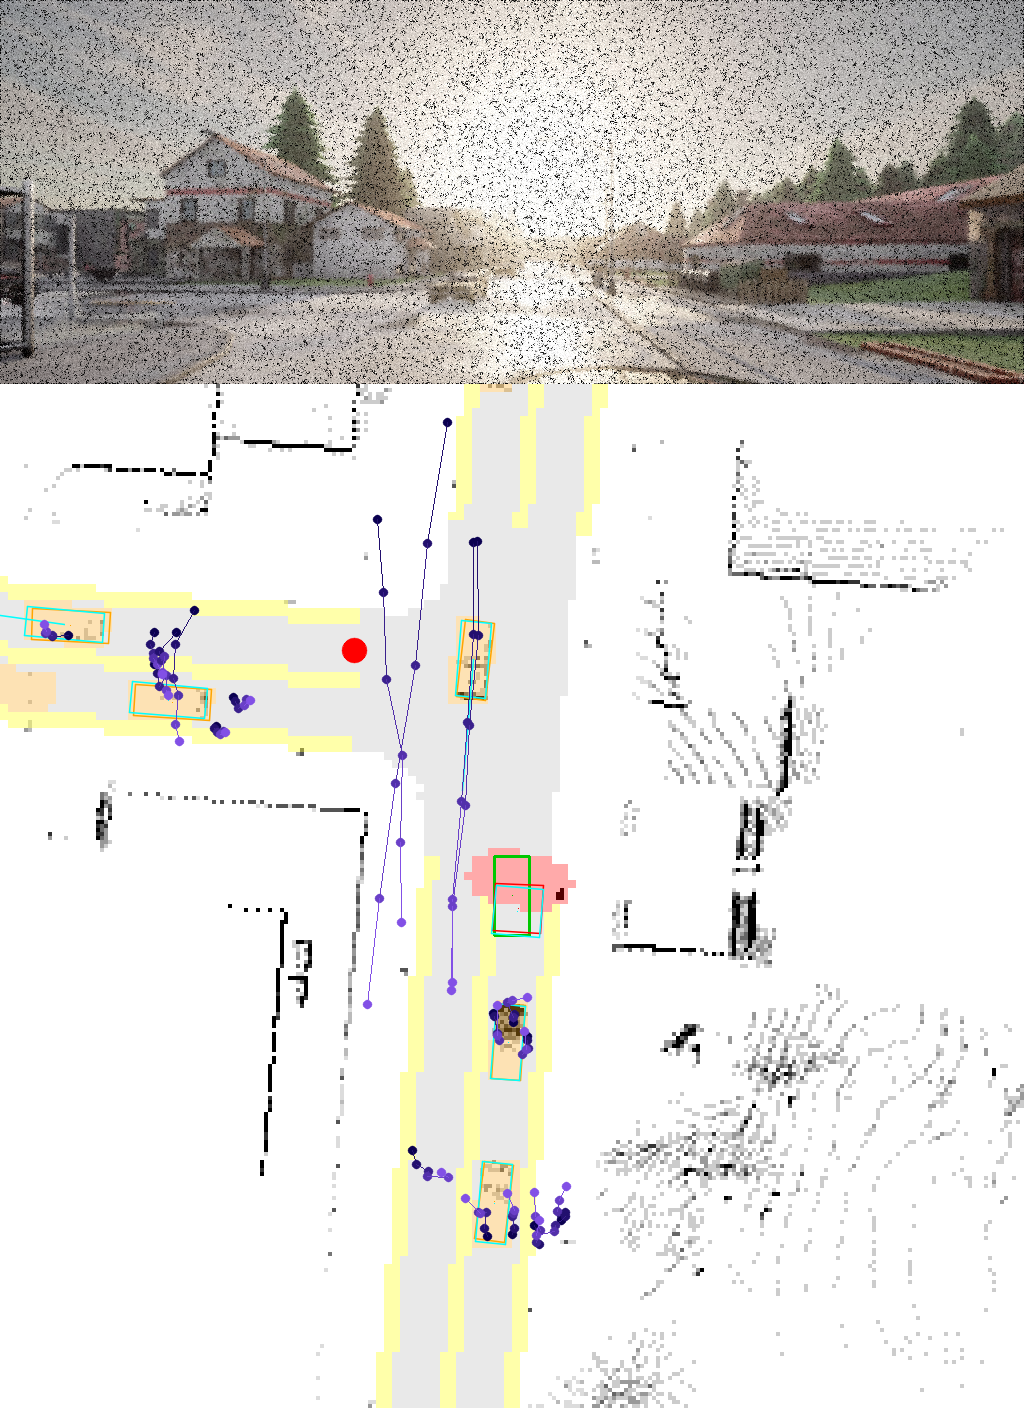

In [37]:
t = -1
rgb = data_point["rgb"][:, t]
lidar_bev = data_point["lidar"][:, t]
target_point = data_point["target_point"][:, t]

pred_trajectories_confidence[0][:, -1] *= -7.345
# pred_trajectories_confidence[0][:10, -1] = pred_trajectories_confidence[0][:10, -1]
# pred_trajectories[0][:10, -1] = pred_trajectories[0][:10, -1]
image = net.visualize_model(
    save_path=None,
    step=0,
    rgb=rgb,
    lidar_bev=lidar_bev,
    target_point=target_point,
    pred_wp=None,
    target_point_next=None,
    pred_semantic=None,
    pred_bev_semantic=None,
    pred_depth=None,
    pred_checkpoint=None,
    pred_speed=None,  # pred_target_speed.softmax(-1),
    pred_target_speed_scalar=None,
    pred_bb=net.convert_features_to_bb_metric(pred_bounding_box),
    pred_trajectories=pred_trajectories,
    pred_trajectory_confidence=pred_trajectories_confidence,
    temporal_attn_weights=None,
    gt_wp=None,
    gt_checkpoints=None,
    gt_bbs=bb,
    gt_speed=None,
    gt_bev_semantic=bev,
    wp_selected=None,
)
# print(pred_trajectories_confidence[0].argmax(-1))
image

In [20]:
index

697